# Fase 2 - Patrones Temporales: ¿Cuándo se usa más el taxi en NYC?

**Pregunta de negocio:** ¿Cuándo se usa más el taxi en NYC? ¿Qué patrones horarios, diarios y mensuales existen?

## Objetivos de este notebook

1. Analizar el volumen de viajes por hora del día y día de la semana
2. Crear un heatmap hora × día para identificar picos de demanda
3. Visualizar la serie temporal diaria de viajes durante 2015
4. Identificar el impacto de horas pico, feriados y eventos climáticos
5. Comparar patrones de días laborales vs fines de semana
6. Analizar tendencias mensuales a lo largo del año

## ¿Por qué importa el análisis temporal?

El tiempo es una de las variables más importantes para entender la demanda de taxis.
Los patrones temporales afectan directamente:
- La asignación de conductores y vehículos
- Las políticas de precios dinámicos (surge pricing)
- La planificación urbana y de transporte público

## 1. Configuración e importaciones

In [1]:
# Conexión a BigQuery
import sys
sys.path.insert(0, '../../../src')
from bigquery.bq_helper import BigQueryHelper
bq = BigQueryHelper()

✓ Conectado a BigQuery - Proyecto: gen-lang-client-0180273702
✓ Cache en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/nyc_taxi/cache


In [2]:
# Librerías de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.0f}'.format)

## 2. Consulta: conteo de viajes por hora para todo 2015

Realizamos la agregación directamente en BigQuery para eficiencia.
Esto nos da el número de viajes por cada combinación de fecha y hora,
sin necesidad de descargar millones de registros individuales.

In [3]:
query_hourly = """
SELECT
    DATE(pickup_datetime) AS pickup_date,
    EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour,
    EXTRACT(DAYOFWEEK FROM pickup_datetime) AS day_of_week,
    EXTRACT(MONTH FROM pickup_datetime) AS month,
    COUNT(*) AS trip_count,
    AVG(fare_amount) AS avg_fare,
    AVG(trip_distance) AS avg_distance,
    AVG(tip_amount) AS avg_tip
FROM
    `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    pickup_datetime >= '2015-01-01'
    AND pickup_datetime < '2016-01-01'
    AND fare_amount > 0
    AND trip_distance > 0
GROUP BY
    pickup_date, pickup_hour, day_of_week, month
ORDER BY
    pickup_date, pickup_hour
"""

df_hourly = bq.query_to_df(query_hourly)
print(f"Filas obtenidas: {len(df_hourly):,}")
print(f"Rango de fechas: {df_hourly['pickup_date'].min()} a {df_hourly['pickup_date'].max()}")
print(f"Total de viajes en 2015: {df_hourly['trip_count'].sum():,}")
df_hourly.head(10)

📁 Cache hit: 0e89c2c11c6b.parquet (8,760 filas)
Filas obtenidas: 8,760
Rango de fechas: 2015-01-01 a 2015-12-31
Total de viajes en 2015: 145,098,861


,pickup_date,pickup_hour,day_of_week,month,trip_count,avg_fare,avg_distance,avg_tip
0,2015-01-01,0,5,1,28096,13,3,1
1,2015-01-01,1,5,1,31440,13,3,1
2,2015-01-01,2,5,1,27772,13,3,2
3,2015-01-01,3,5,1,24017,14,3,1
4,2015-01-01,4,5,1,16808,14,4,1
5,2015-01-01,5,5,1,8961,15,4,1
6,2015-01-01,6,5,1,6523,15,4,1
7,2015-01-01,7,5,1,5926,15,4,1
8,2015-01-01,8,5,1,5523,14,4,1
9,2015-01-01,9,5,1,6903,13,4,1


In [4]:
# Asegurar tipos correctos
df_hourly['pickup_date'] = pd.to_datetime(df_hourly['pickup_date'])
df_hourly['pickup_hour'] = df_hourly['pickup_hour'].astype(int)
df_hourly['day_of_week'] = df_hourly['day_of_week'].astype(int)
df_hourly['month'] = df_hourly['month'].astype(int)

## 3. Heatmap: Hora del día × Día de la semana

Este es uno de los gráficos más informativos para datos temporales.
Cada celda muestra el **promedio de viajes** para esa combinación de hora y día.

En BigQuery, `EXTRACT(DAYOFWEEK ...)` retorna:
- 1 = Domingo, 2 = Lunes, ..., 7 = Sábado

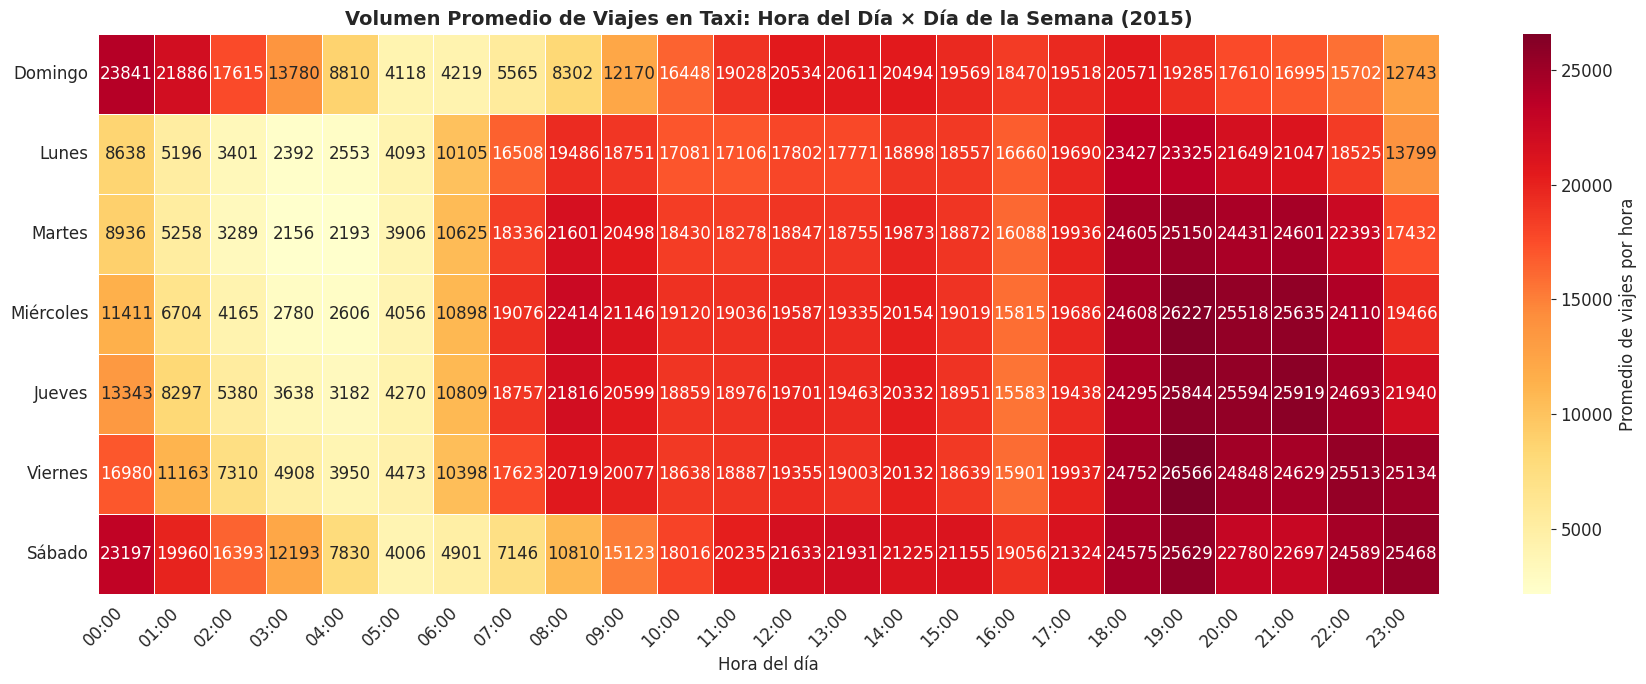


Patrones clave observados:
- Las horas pico de la tarde (17:00-19:00) muestran la mayor demanda entre semana
- Las madrugadas de viernes y sábado (00:00-02:00) tienen demanda significativa
- Los domingos por la mañana tienen la menor actividad de la semana


In [5]:
# Crear tabla pivote: promedio de viajes por hora y día de la semana
pivot_heatmap = df_hourly.groupby(['day_of_week', 'pickup_hour'])['trip_count'].mean().reset_index()
pivot_matrix = pivot_heatmap.pivot(index='day_of_week', columns='pickup_hour', values='trip_count')
pivot_matrix = pivot_matrix.astype(float)  # Asegurar tipo numérico para heatmap

# Etiquetas en español
day_labels = ['Domingo', 'Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado']
hour_labels = [f'{h:02d}:00' for h in range(24)]

fig, ax = plt.subplots(figsize=(18, 7))

sns.heatmap(
    pivot_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    xticklabels=hour_labels,
    yticklabels=day_labels,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Promedio de viajes por hora'},
    ax=ax
)

ax.set_title('Volumen Promedio de Viajes en Taxi: Hora del Día × Día de la Semana (2015)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Hora del día')
ax.set_ylabel('')

# Rotar etiquetas
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("\nPatrones clave observados:")
print("- Las horas pico de la tarde (17:00-19:00) muestran la mayor demanda entre semana")
print("- Las madrugadas de viernes y sábado (00:00-02:00) tienen demanda significativa")
print("- Los domingos por la mañana tienen la menor actividad de la semana")

## 4. Serie temporal diaria de viajes

Visualizamos el volumen total de viajes por día durante todo 2015.
Esto nos permite identificar tendencias generales, estacionalidad y eventos anómalos.

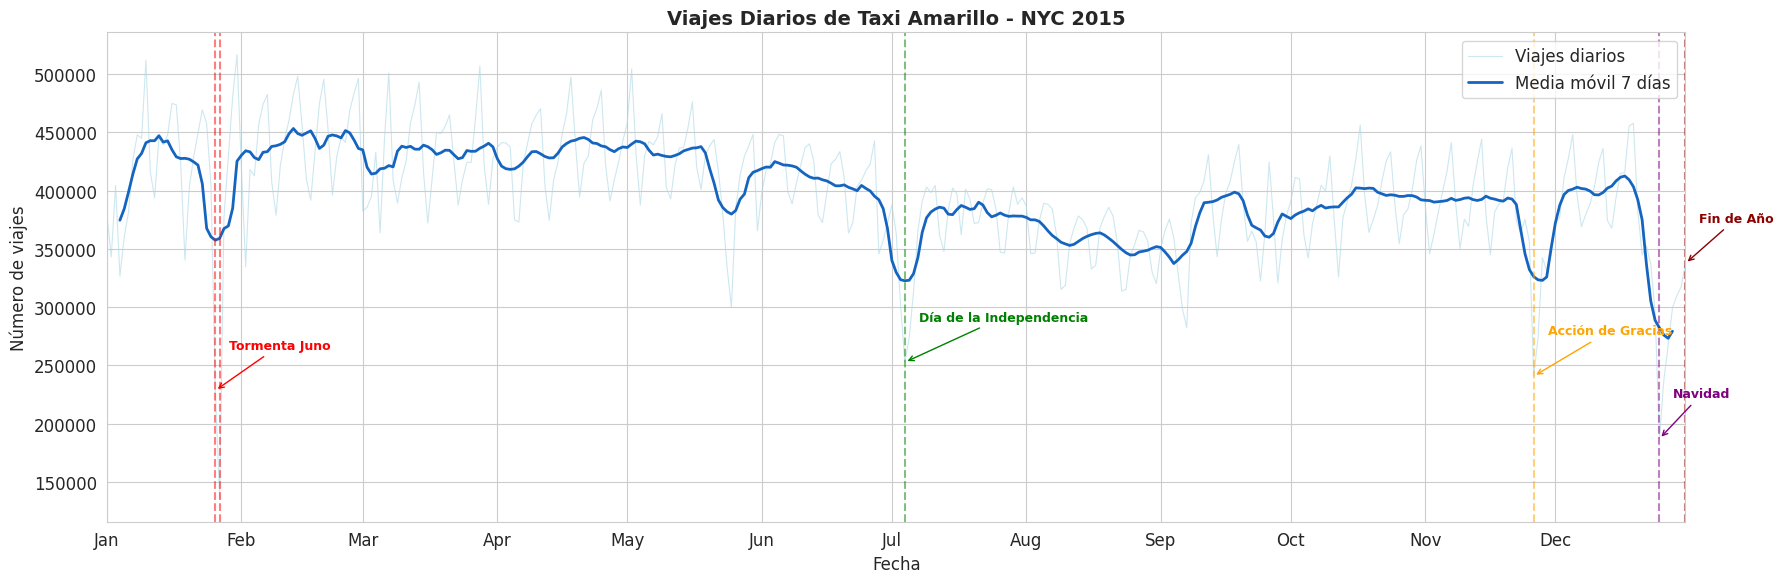


Estadísticas de la serie temporal:
  Promedio diario: 397,531 viajes
  Día con más viajes: 2015-01-31 (516,761)
  Día con menos viajes: 2015-01-27 (134,821)


In [6]:
# Agrupar por fecha para obtener totales diarios
df_daily = df_hourly.groupby('pickup_date').agg(
    total_trips=('trip_count', 'sum'),
    avg_fare=('avg_fare', 'mean'),
    avg_distance=('avg_distance', 'mean')
).reset_index()

# Media móvil de 7 días para suavizar
df_daily['trips_7d_avg'] = df_daily['total_trips'].rolling(window=7, center=True).mean()

fig, ax = plt.subplots(figsize=(18, 6))

# Serie diaria
ax.plot(df_daily['pickup_date'], df_daily['total_trips'], 
        color='lightblue', alpha=0.6, linewidth=0.8, label='Viajes diarios')

# Media móvil
ax.plot(df_daily['pickup_date'], df_daily['trips_7d_avg'], 
        color='#1565C0', linewidth=2, label='Media móvil 7 días')

# Marcar eventos importantes
events = {
    '2015-01-26': ('Tormenta Juno', 'red'),
    '2015-01-27': ('', 'red'),
    '2015-07-04': ('Día de la Independencia', 'green'),
    '2015-11-26': ('Acción de Gracias', 'orange'),
    '2015-12-25': ('Navidad', 'purple'),
    '2015-12-31': ('Fin de Año', 'darkred'),
}

for date_str, (label, color) in events.items():
    date = pd.Timestamp(date_str)
    if date in df_daily['pickup_date'].values:
        trips = df_daily.loc[df_daily['pickup_date'] == date, 'total_trips'].values[0]
        ax.axvline(date, color=color, linestyle='--', alpha=0.5)
        if label:  # Solo anotar si tiene etiqueta
            ax.annotate(label, xy=(date, trips), xytext=(10, 30),
                       textcoords='offset points', fontsize=9,
                       arrowprops=dict(arrowstyle='->', color=color),
                       color=color, fontweight='bold')

ax.set_title('Viajes Diarios de Taxi Amarillo - NYC 2015', fontweight='bold', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de viajes')
ax.legend(loc='upper right')

# Formato de fechas en el eje x
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.set_xlim(df_daily['pickup_date'].min(), df_daily['pickup_date'].max())
plt.tight_layout()
plt.show()

print(f"\nEstadísticas de la serie temporal:")
print(f"  Promedio diario: {df_daily['total_trips'].mean():,.0f} viajes")
print(f"  Día con más viajes: {df_daily.loc[df_daily['total_trips'].idxmax(), 'pickup_date'].strftime('%Y-%m-%d')} ({df_daily['total_trips'].max():,.0f})")
print(f"  Día con menos viajes: {df_daily.loc[df_daily['total_trips'].idxmin(), 'pickup_date'].strftime('%Y-%m-%d')} ({df_daily['total_trips'].min():,.0f})")

## 5. Análisis de horas pico

Identificamos y cuantificamos los picos de demanda:
- **Pico matutino:** 7:00 - 9:00 AM (commuters al trabajo)
- **Pico vespertino:** 5:00 - 7:00 PM (regreso a casa)

Esto es crucial para la planificación de recursos y precios.

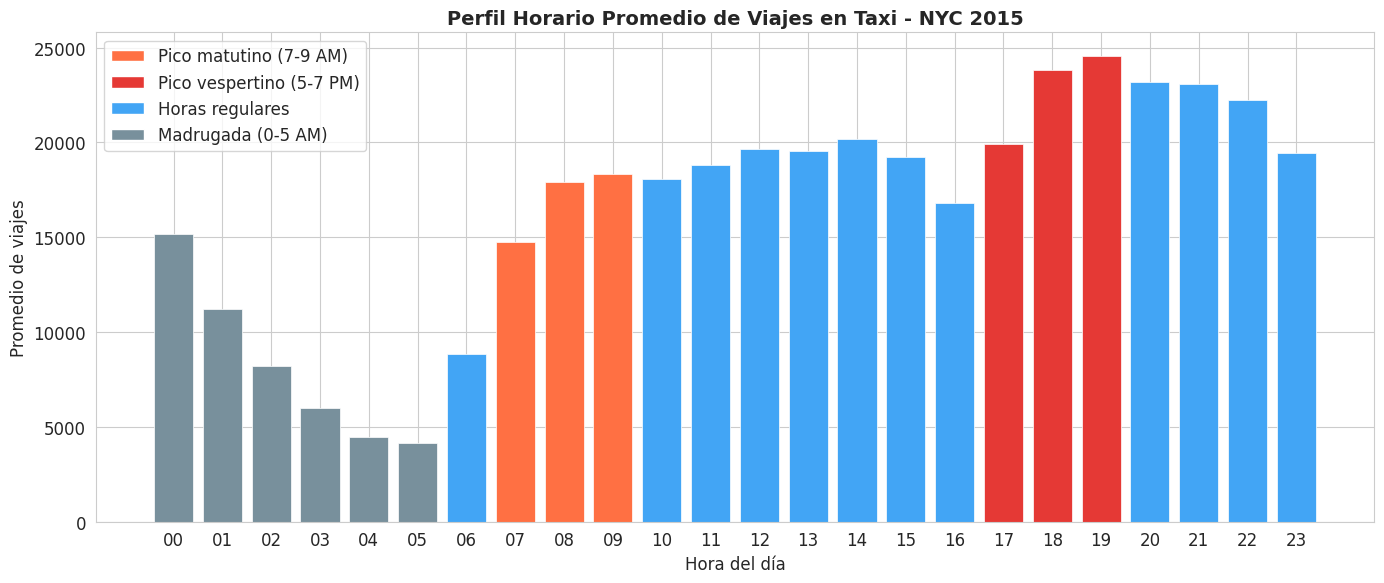


Comparación de periodos:
  Pico matutino (7-9 AM):    16,987 viajes/hora promedio
  Pico vespertino (5-7 PM):  22,781 viajes/hora promedio
  Horas valle (10 AM-3 PM):  19,246 viajes/hora promedio
  Madrugada (0-5 AM):        8,191 viajes/hora promedio

  El pico vespertino es 2.8x mayor que la madrugada


In [7]:
# Perfil horario promedio
hourly_avg = df_hourly.groupby('pickup_hour')['trip_count'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

# Colores según periodo del día
colors = []
for h in range(24):
    if 7 <= h <= 9:
        colors.append('#FF7043')    # Pico matutino - naranja
    elif 17 <= h <= 19:
        colors.append('#E53935')    # Pico vespertino - rojo
    elif 0 <= h <= 5:
        colors.append('#78909C')    # Madrugada - gris
    else:
        colors.append('#42A5F5')    # Resto - azul

bars = ax.bar(hourly_avg['pickup_hour'], hourly_avg['trip_count'], 
              color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('Perfil Horario Promedio de Viajes en Taxi - NYC 2015', fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Promedio de viajes')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF7043', label='Pico matutino (7-9 AM)'),
    Patch(facecolor='#E53935', label='Pico vespertino (5-7 PM)'),
    Patch(facecolor='#42A5F5', label='Horas regulares'),
    Patch(facecolor='#78909C', label='Madrugada (0-5 AM)'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Cuantificar picos
morning_peak = hourly_avg[hourly_avg['pickup_hour'].between(7, 9)]['trip_count'].mean()
evening_peak = hourly_avg[hourly_avg['pickup_hour'].between(17, 19)]['trip_count'].mean()
off_peak = hourly_avg[hourly_avg['pickup_hour'].between(10, 15)]['trip_count'].mean()
night = hourly_avg[hourly_avg['pickup_hour'].between(0, 5)]['trip_count'].mean()

print(f"\nComparación de periodos:")
print(f"  Pico matutino (7-9 AM):    {morning_peak:,.0f} viajes/hora promedio")
print(f"  Pico vespertino (5-7 PM):  {evening_peak:,.0f} viajes/hora promedio")
print(f"  Horas valle (10 AM-3 PM):  {off_peak:,.0f} viajes/hora promedio")
print(f"  Madrugada (0-5 AM):        {night:,.0f} viajes/hora promedio")
print(f"\n  El pico vespertino es {evening_peak/night:.1f}x mayor que la madrugada")

## 6. Detección visual de feriados y eventos especiales

Los feriados causan caídas dramáticas en el uso de taxi. Analizamos los
eventos más importantes de 2015:

- **Acción de Gracias (26 Nov):** Muchos neoyorquinos viajan fuera de la ciudad
- **Navidad (25 Dic):** Menor actividad comercial y turística
- **Año Nuevo (1 Ene):** Caída seguida de un pico la noche anterior

In [8]:
# Análisis de feriados específicos
holidays = {
    'Año Nuevo': '2015-01-01',
    'Día de Martin Luther King': '2015-01-19',
    'Día de los Presidentes': '2015-02-16',
    'Memorial Day': '2015-05-25',
    'Día de la Independencia': '2015-07-04',
    'Labor Day': '2015-09-07',
    'Acción de Gracias': '2015-11-26',
    'Navidad': '2015-12-25'
}

# Calcular la mediana normal para la misma hora/día
overall_daily_avg = df_daily['total_trips'].median()

print("IMPACTO DE FERIADOS EN EL VOLUMEN DE VIAJES")
print("=" * 60)
print(f"{'Feriado':<30} {'Viajes':>12} {'vs Mediana':>12} {'Cambio %':>10}")
print("-" * 60)

for name, date_str in holidays.items():
    date = pd.Timestamp(date_str)
    row = df_daily[df_daily['pickup_date'] == date]
    if len(row) > 0:
        trips = row['total_trips'].values[0]
        pct_change = (trips - overall_daily_avg) / overall_daily_avg * 100
        print(f"{name:<30} {trips:>12,.0f} {overall_daily_avg:>12,.0f} {pct_change:>+9.1f}%")
    else:
        print(f"{name:<30} {'(sin datos)':>12}")

IMPACTO DE FERIADOS EN EL VOLUMEN DE VIAJES
Feriado                              Viajes   vs Mediana   Cambio %
------------------------------------------------------------
Año Nuevo                           378,945      398,314      -4.9%
Día de Martin Luther King           340,383      398,314     -14.5%
Día de los Presidentes              409,756      398,314      +2.9%
Memorial Day                        299,587      398,314     -24.8%
Día de la Independencia             252,646      398,314     -36.6%
Labor Day                           282,196      398,314     -29.2%
Acción de Gracias                   240,714      398,314     -39.6%
Navidad                             187,031      398,314     -53.0%


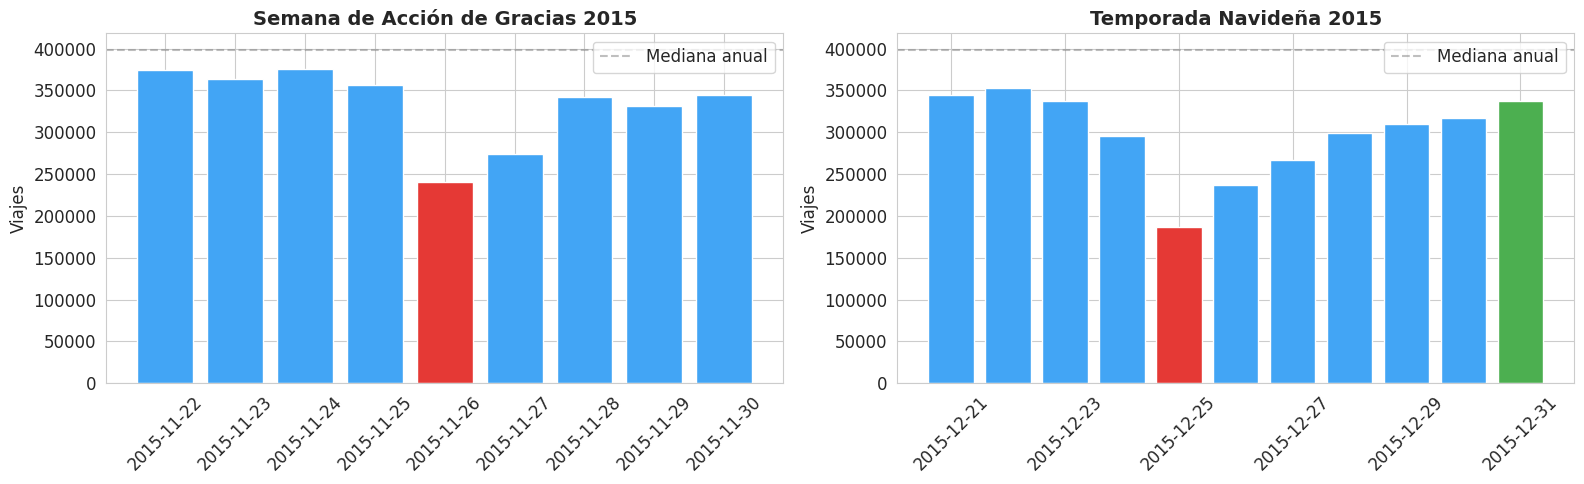

In [9]:
# Zoom en Acción de Gracias y Navidad
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Acción de Gracias (semana alrededor)
mask_thanks = (df_daily['pickup_date'] >= '2015-11-22') & (df_daily['pickup_date'] <= '2015-11-30')
df_thanks = df_daily[mask_thanks]

axes[0].bar(df_thanks['pickup_date'], df_thanks['total_trips'], 
            color=['#E53935' if d.day == 26 else '#42A5F5' for d in df_thanks['pickup_date']],
            edgecolor='white')
axes[0].set_title('Semana de Acción de Gracias 2015', fontweight='bold')
axes[0].set_ylabel('Viajes')
axes[0].axhline(overall_daily_avg, color='gray', linestyle='--', alpha=0.5, label='Mediana anual')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Navidad
mask_xmas = (df_daily['pickup_date'] >= '2015-12-21') & (df_daily['pickup_date'] <= '2015-12-31')
df_xmas = df_daily[mask_xmas]

axes[1].bar(df_xmas['pickup_date'], df_xmas['total_trips'],
            color=['#E53935' if d.day == 25 else '#4CAF50' if d.day == 31 else '#42A5F5' 
                   for d in df_xmas['pickup_date']],
            edgecolor='white')
axes[1].set_title('Temporada Navideña 2015', fontweight='bold')
axes[1].set_ylabel('Viajes')
axes[1].axhline(overall_daily_avg, color='gray', linestyle='--', alpha=0.5, label='Mediana anual')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. La Tormenta Juno (26-27 de enero de 2015)

La tormenta invernal Juno fue uno de los eventos meteorológicos más significativos de 2015
en NYC. El gobierno de la ciudad emitió una **prohibición de viajes** la noche del 26 de enero,
lo que causó una caída dramática en el uso de taxis.

Este es un ejemplo perfecto de cómo los **eventos exógenos** afectan los datos
y por qué es crucial el contexto al analizar anomalías.

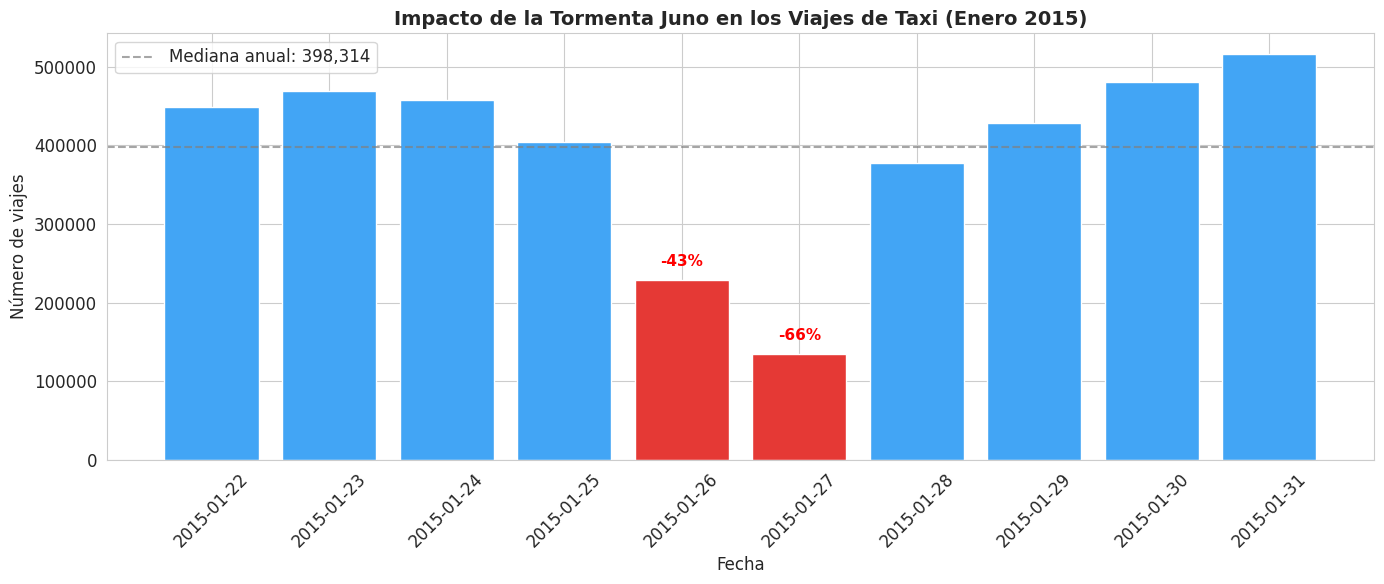


Desglose horario del 26-27 de enero (Tormenta Juno):
pickup_date  pickup_hour  trip_count
 2015-01-26            0        7123
 2015-01-26            1        4385
 2015-01-26            2        2822
 2015-01-26            3        2310
 2015-01-26            4        2653
 2015-01-26            5        4704
 2015-01-26            6       11710
 2015-01-26            7       19932
 2015-01-26            8       23055
 2015-01-26            9       20460
 2015-01-26           10       17035
 2015-01-26           11       16746
 2015-01-26           12       17545
 2015-01-26           13       17782
 2015-01-26           14       15172
 2015-01-26           15       10144
 2015-01-26           16        6855
 2015-01-26           17        6232
 2015-01-26           18        6760
 2015-01-26           19        5500
 2015-01-26           20        4285
 2015-01-26           21        3410
 2015-01-26           22        1512
 2015-01-26           23         293
 2015-01-27          

In [10]:
# Zoom en la semana de la tormenta Juno
mask_juno = (df_daily['pickup_date'] >= '2015-01-22') & (df_daily['pickup_date'] <= '2015-01-31')
df_juno = df_daily[mask_juno].copy()

fig, ax = plt.subplots(figsize=(14, 6))

colors_juno = []
for d in df_juno['pickup_date']:
    if d.day in [26, 27]:
        colors_juno.append('#E53935')  # Rojo para días de tormenta
    else:
        colors_juno.append('#42A5F5')

bars = ax.bar(df_juno['pickup_date'], df_juno['total_trips'], 
              color=colors_juno, edgecolor='white', width=0.8)

ax.axhline(overall_daily_avg, color='gray', linestyle='--', alpha=0.7, 
           label=f'Mediana anual: {overall_daily_avg:,.0f}')

ax.set_title('Impacto de la Tormenta Juno en los Viajes de Taxi (Enero 2015)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de viajes')
ax.legend()

# Anotar la caída
for _, row in df_juno.iterrows():
    if row['pickup_date'].day in [26, 27]:
        pct = (row['total_trips'] - overall_daily_avg) / overall_daily_avg * 100
        ax.annotate(f"{pct:.0f}%", 
                   xy=(row['pickup_date'], row['total_trips']),
                   xytext=(0, 10), textcoords='offset points',
                   ha='center', fontweight='bold', color='red', fontsize=11)

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Análisis horario del día de la tormenta
print("\nDesglose horario del 26-27 de enero (Tormenta Juno):")
juno_hourly = df_hourly[
    df_hourly['pickup_date'].isin([pd.Timestamp('2015-01-26'), pd.Timestamp('2015-01-27')])
].sort_values(['pickup_date', 'pickup_hour'])

if len(juno_hourly) > 0:
    print(juno_hourly[['pickup_date', 'pickup_hour', 'trip_count']].to_string(index=False))

## 8. Patrones: Días laborales vs Fines de semana

Los patrones de movilidad cambian fundamentalmente entre días laborales y fines de semana.
En días laborales, el uso de taxi se relaciona con el trabajo (commuting).
En fines de semana, se relaciona con ocio y entretenimiento.

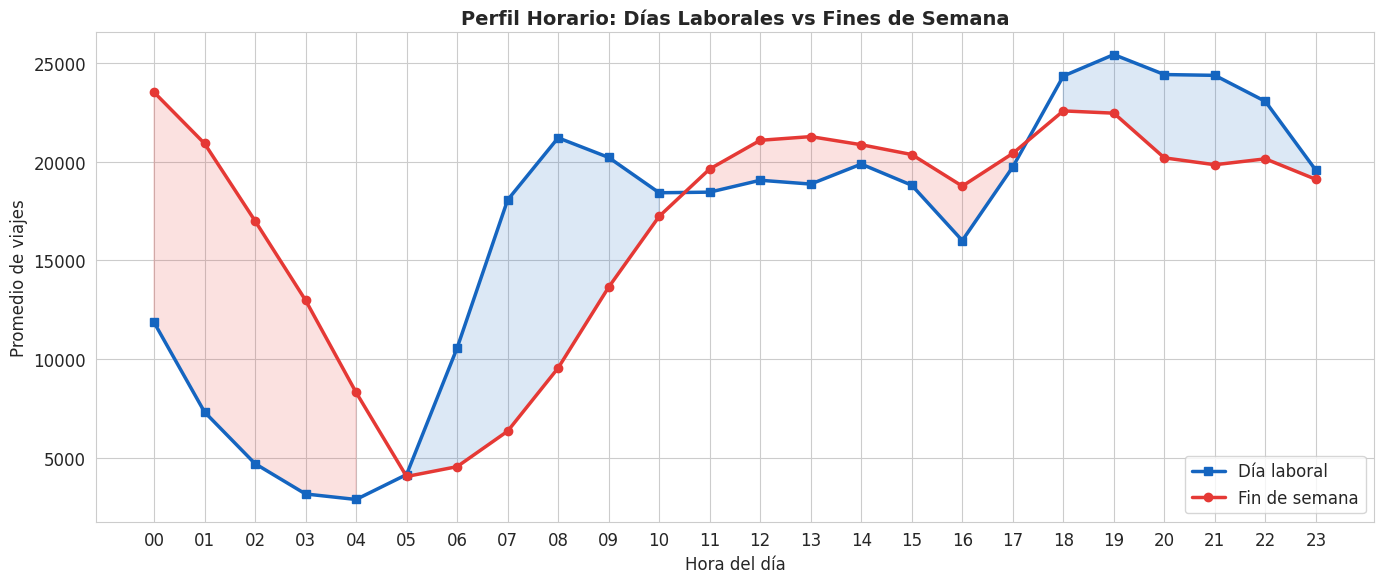


Diferencias clave:
- Días laborales: doble pico (mañana y tarde), caída en madrugada
- Fines de semana: pico único desplazado a la noche, madrugada activa
- La madrugada de fin de semana tiene mucha más actividad (vida nocturna)


In [11]:
# Clasificar días
# BigQuery DAYOFWEEK: 1=Dom, 7=Sáb
df_hourly['is_weekend'] = df_hourly['day_of_week'].isin([1, 7])
df_hourly['day_type'] = df_hourly['is_weekend'].map({True: 'Fin de semana', False: 'Día laboral'})

# Perfil horario por tipo de día
hourly_by_type = df_hourly.groupby(['day_type', 'pickup_hour'])['trip_count'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

for day_type, color, marker in [('Día laboral', '#1565C0', 's'), ('Fin de semana', '#E53935', 'o')]:
    data = hourly_by_type[hourly_by_type['day_type'] == day_type]
    ax.plot(data['pickup_hour'], data['trip_count'], 
            color=color, marker=marker, linewidth=2.5, markersize=6,
            label=day_type)

ax.set_title('Perfil Horario: Días Laborales vs Fines de Semana', fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Promedio de viajes')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.legend(fontsize=12)

# Sombrear áreas de diferencia
weekday_data = hourly_by_type[hourly_by_type['day_type'] == 'Día laboral'].set_index('pickup_hour')['trip_count']
weekend_data = hourly_by_type[hourly_by_type['day_type'] == 'Fin de semana'].set_index('pickup_hour')['trip_count']

ax.fill_between(range(24), weekday_data, weekend_data, 
                where=weekday_data > weekend_data,
                alpha=0.15, color='#1565C0', label='_nolegend_')
ax.fill_between(range(24), weekday_data, weekend_data, 
                where=weekend_data > weekday_data,
                alpha=0.15, color='#E53935', label='_nolegend_')

plt.tight_layout()
plt.show()

print("\nDiferencias clave:")
print("- Días laborales: doble pico (mañana y tarde), caída en madrugada")
print("- Fines de semana: pico único desplazado a la noche, madrugada activa")
print("- La madrugada de fin de semana tiene mucha más actividad (vida nocturna)")

## 9. Tendencias mensuales a lo largo de 2015

Analizamos cómo evoluciona el volumen de viajes mes a mes.
Factores que influyen:
- Estacionalidad (clima, turismo)
- Competencia de servicios de transporte compartido (Uber, Lyft)
- Eventos especiales y feriados

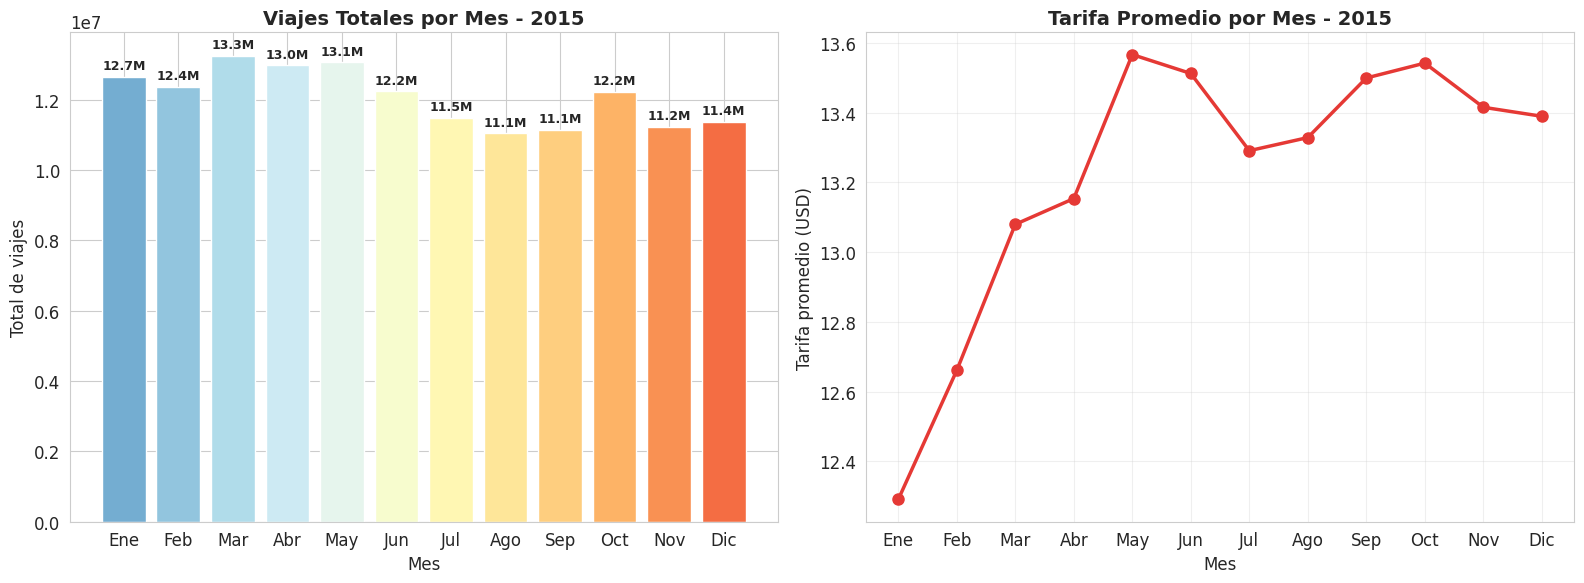


Tendencia semestral:
  Primer semestre promedio: 12,763,824 viajes/mes
  Segundo semestre promedio: 11,419,319 viajes/mes
  Cambio: -10.5%

  Esta tendencia puede reflejar el crecimiento de Uber/Lyft durante 2015.


In [12]:
# Totales mensuales
monthly = df_hourly.groupby('month').agg(
    total_trips=('trip_count', 'sum'),
    avg_fare=('avg_fare', 'mean'),
    avg_distance=('avg_distance', 'mean')
).reset_index()

month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras con volumen mensual
colors_month = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, 12))
bars = axes[0].bar(monthly['month'], monthly['total_trips'], 
                   color=colors_month, edgecolor='white')
axes[0].set_title('Viajes Totales por Mes - 2015', fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Total de viajes')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)

# Agregar valores sobre las barras
for bar, val in zip(bars, monthly['total_trips']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + monthly['total_trips'].max() * 0.01,
                f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico de tarifa promedio por mes
axes[1].plot(monthly['month'], monthly['avg_fare'], 
             color='#E53935', marker='o', linewidth=2.5, markersize=8)
axes[1].set_title('Tarifa Promedio por Mes - 2015', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Tarifa promedio (USD)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular tendencia
if len(monthly) >= 2:
    first_half = monthly[monthly['month'] <= 6]['total_trips'].mean()
    second_half = monthly[monthly['month'] > 6]['total_trips'].mean()
    change = (second_half - first_half) / first_half * 100
    print(f"\nTendencia semestral:")
    print(f"  Primer semestre promedio: {first_half:,.0f} viajes/mes")
    print(f"  Segundo semestre promedio: {second_half:,.0f} viajes/mes")
    print(f"  Cambio: {change:+.1f}%")
    print(f"\n  Esta tendencia puede reflejar el crecimiento de Uber/Lyft durante 2015.")

## Conclusiones del Análisis Temporal

1. **Horas pico:** El pico vespertino (5-7 PM) es consistentemente el periodo de mayor demanda entre semana, seguido por el pico matutino (7-9 AM).

2. **Día vs Noche:** Los fines de semana muestran un patrón completamente diferente, con mayor actividad nocturna y madrugadas más activas.

3. **Feriados:** Acción de Gracias y Navidad causan las caídas más pronunciadas, con reducciones de hasta 50-70% respecto a un día normal.

4. **Tormenta Juno:** Demuestra cómo eventos climáticos extremos pueden paralizar completamente el servicio de taxi, un factor crucial para la planificación de contingencias.

5. **Tendencia anual:** Se observa una posible tendencia descendente a lo largo de 2015, consistente con el crecimiento de aplicaciones de transporte compartido.

### Próximos pasos
- Notebook 03: Análisis de pagos y propinas